# 1pMCRI Motion Correction Notebook

Edit parameters and run piecewise non-rigid motion correction.

In [1]:
from pathlib import Path
from dataclasses import asdict
import sys
import importlib.util

import numpy as np
import torch
import tifffile
import matplotlib.pyplot as plt

In [2]:
repo_root = Path.cwd().resolve()
while not (repo_root / "pyproject.toml").exists() and repo_root.parent != repo_root:
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
script_path = repo_root / "dev" / "1pMCRI_motion_correct_data.py"

spec = importlib.util.spec_from_file_location("mcri_motion", script_path)
mcri_motion = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(mcri_motion)

print(f"Loaded: {script_path}")

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),NVIDIA GeForce RTX 3090,DiscreteGPU,Vulkan,560.94
✅,NVIDIA GeForce RTX 3090,DiscreteGPU,D3D12,
✅,NVIDIA GeForce RTX 3090,DiscreteGPU,D3D12,
❗ limited,Microsoft Basic Render Driver,CPU,D3D12,
❌,NVIDIA GeForce RTX 3090/PCIe/SSE2,Unknown,OpenGL,4.6.0 NVIDIA 560.94


To silence this warning, use a fully namespaced name.


Loaded: \\mmlabnas4\mouse-manipulandum-neural\code\masknmf-toolbox\dev\1pMCRI_motion_correct_data.py


## Parameters
- `input_image_path`: Input TIFF file path (2D or 3D).
- `out_path`: Output HDF5 (`.h5`) path.
- `out_tiff_path`: Output TIFF stack (`.tif`) path. If `None`, uses `out_path` with `.tif` extension.
- `out_extract_h5_path`: Output EXTRACT-compatible HDF5 path.
- `export_tiff_stack`: If `True`, also export a TIFF stack.
- `export_extract_h5`: If `True`, export EXTRACT-compatible HDF5 (`/mov` as `[H,W,T]`).
- `extract_h5_dtype`: `"uint16"` (recommended) or `"float32"`.
- `num_blocks_dim1`, `num_blocks_dim2`: Number of registration blocks along height and width.
- `overlaps_dim1`, `overlaps_dim2`: Overlap size between neighboring blocks (pixels).
- `max_rigid_shifts_dim1`, `max_rigid_shifts_dim2`: Maximum global rigid shift allowed (pixels).
- `max_deviation_rigid_dim1`, `max_deviation_rigid_dim2`: Maximum per-block deviation from global rigid shift (pixels).
- `frame_batch_size`: Frames processed per batch (higher is faster, uses more memory).
- `spatial_highpass_sigma`: Spatial high-pass sigma used only for shift estimation. Disable with `<= 0`.
- `device`: `"auto"`, `"cpu"`, `"cuda"`.

In [3]:
# Edit values and run
config = mcri_motion.MotionCorrectionConfig(
    input_image_path=str(repo_root / "demo_data" / "250810-Ras2-GC#78_reg_t_crop_s_full.tif"),
    out_path=str(repo_root / "demo_data" / "output" / "moco_results.h5"),
    out_tiff_path=str(repo_root / "demo_data" / "output" / "moco_results.tif"),
    out_extract_h5_path=str(repo_root / "demo_data" / "output" / "moco_results_extract.h5"),
    export_tiff_stack=True,
    export_extract_h5=True,
    extract_h5_dtype="uint16",
    num_blocks_dim1=20,
    num_blocks_dim2=20,
    overlaps_dim1=25,
    overlaps_dim2=25,
    max_rigid_shifts_dim1=15,
    max_rigid_shifts_dim2=15,
    max_deviation_rigid_dim1=10,
    max_deviation_rigid_dim2=10,
    frame_batch_size=20,
    spatial_highpass_sigma=3.0,
    device="auto",
)

config

MotionCorrectionConfig(input_image_path='\\\\mmlabnas4\\mouse-manipulandum-neural\\code\\masknmf-toolbox\\demo_data\\250810-Ras2-GC#78_reg_t_crop_s_full.tif', out_path='\\\\mmlabnas4\\mouse-manipulandum-neural\\code\\masknmf-toolbox\\demo_data\\output\\moco_results.h5', out_tiff_path='\\\\mmlabnas4\\mouse-manipulandum-neural\\code\\masknmf-toolbox\\demo_data\\output\\moco_results.tif', out_extract_h5_path='\\\\mmlabnas4\\mouse-manipulandum-neural\\code\\masknmf-toolbox\\demo_data\\output\\moco_results_extract.h5', export_tiff_stack=True, export_extract_h5=True, extract_h5_dtype='uint16', num_blocks_dim1=20, num_blocks_dim2=20, overlaps_dim1=25, overlaps_dim2=25, max_rigid_shifts_dim1=15, max_rigid_shifts_dim2=15, max_deviation_rigid_dim1=10, max_deviation_rigid_dim2=10, frame_batch_size=20, spatial_highpass_sigma=3.0, device='auto')

## High-Pass Preview (Single Frame)
Visualize one frame before and after spatial high-pass filtering.

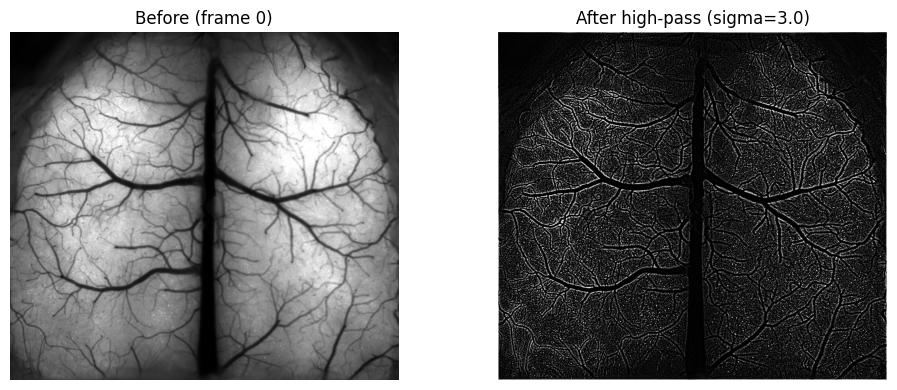

Preview device: cuda


In [4]:
if config.spatial_highpass_sigma <= 0:
    raise ValueError("Set config.spatial_highpass_sigma > 0 to preview high-pass filtering.")

preview_strategy = mcri_motion.masknmf.PiecewiseRigidMotionCorrector(
    num_blocks=(config.num_blocks_dim1, config.num_blocks_dim2),
    overlaps=(config.overlaps_dim1, config.overlaps_dim2),
    max_rigid_shifts=(config.max_rigid_shifts_dim1, config.max_rigid_shifts_dim2),
    max_deviation_rigid=(config.max_deviation_rigid_dim1, config.max_deviation_rigid_dim2),
    batch_size=config.frame_batch_size,
    device=config.device,
)
resolved_device = preview_strategy.device

frame_index = 0
raw_frame = tifffile.imread(config.input_image_path, key=frame_index).astype(np.float32)
if raw_frame.ndim == 3:
    raw_frame = raw_frame[0]

filter_fn = mcri_motion.build_highpass_filter(config.spatial_highpass_sigma, resolved_device)
raw_tensor = torch.from_numpy(raw_frame)[None, :, :].to(resolved_device)
hp_frame = filter_fn(raw_tensor).squeeze(0).detach().cpu().numpy()

vmin_raw, vmax_raw = np.percentile(raw_frame, [1, 99])
vmin_hp, vmax_hp = np.percentile(hp_frame, [1, 99])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(raw_frame, cmap="gray", vmin=vmin_raw, vmax=vmax_raw)
axes[0].set_title(f"Before (frame {frame_index})")
axes[0].axis("off")
axes[1].imshow(hp_frame, cmap="gray", vmin=vmin_hp, vmax=vmax_hp)
axes[1].set_title(f"After high-pass (sigma={config.spatial_highpass_sigma})")
axes[1].axis("off")
plt.tight_layout()
plt.show()
print(f"Preview device: {resolved_device}")

In [5]:
def run_with_oom_retry(base_config):
    batch_candidates = []
    b = int(base_config.frame_batch_size)
    while b >= 16:
        batch_candidates.append(b)
        b //= 2
    if 16 not in batch_candidates:
        batch_candidates.append(16)

    last_err = None
    for bsz in batch_candidates:
        cfg = mcri_motion.MotionCorrectionConfig(**{**asdict(base_config), "frame_batch_size": bsz})
        try:
            print(f"Trying device={cfg.device}, frame_batch_size={cfg.frame_batch_size}")
            return mcri_motion.run_motion_correction(cfg)
        except RuntimeError as e:
            last_err = e
            msg = str(e).lower()
            if "out of memory" in msg and "cuda" in msg:
                print(f"CUDA OOM at batch_size={bsz}. Retrying with smaller batch...")
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                continue
            raise

    if base_config.device != "cpu":
        cpu_cfg = mcri_motion.MotionCorrectionConfig(**{**asdict(base_config), "device": "cpu", "frame_batch_size": max(16, min(64, base_config.frame_batch_size))})
        print(f"Falling back to CPU: device={cpu_cfg.device}, frame_batch_size={cpu_cfg.frame_batch_size}")
        return mcri_motion.run_motion_correction(cpu_cfg)

    raise last_err if last_err is not None else RuntimeError("Motion correction failed")


out_file = run_with_oom_retry(config)
print(f"Completed. Output: {out_file}")

Trying device=auto, frame_batch_size=20


Input movie shape: (400, 1700, 1900)
Motion correction device: cuda
Using spatial high-pass for shift estimation (sigma=3.0)


\\mmlabnas4\mouse-manipulandum-neural\code\masknmf-toolbox\masknmf\motion_correction\strategies.py:163: UserWarning: Using less than 500 frames to create registration template
  warnings.warn("Using less than 500 frames to create registration template")


  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [00:03<00:03,  3.55s/it]

...

100%|██████████| 2/2 [00:12<00:00,  6.08s/it]

Exporting motion-corrected movie to: \\mmlabnas4\mouse-manipulandum-neural\code\masknmf-toolbox\demo_data\output\moco_results.h5


Exporting motion-corrected TIFF stack to: \\mmlabnas4\mouse-manipulandum-neural\code\masknmf-toolbox\demo_data\output\moco_results.tif


Exporting EXTRACT-compatible HDF5 to: \\mmlabnas4\mouse-manipulandum-neural\code\masknmf-toolbox\demo_data\output\moco_results_extract.h5


Done.
Completed. Output: \\mmlabnas4\mouse-manipulandum-neural\code\masknmf-toolbox\demo_data\output\moco_results.h5
